In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:

def next_pow_two(n):
    """
    find the next power of 2 given n
    """
    i = 1
    while i < n:
        i = i << 1
    return i

def autocorrelation(x, norm=True):
    """
    compute the autocorrelation function of an array
    """
    x = np.atleast_1d(x)
    if len(x.shape) != 1:
        raise ValueError("invalid dimensions for 1D autocorrelation function")
    n = next_pow_two(len(x))

    # Compute the FFT and then (from that) the auto-correlation function
    f = np.fft.fft(x - np.mean(x), n=2 * n)
    acf = np.fft.ifft(f * np.conjugate(f))[: len(x)].real
    acf /= 4 * n

    # Optionally normalize
    if norm:
        acf /= acf[0]

    return acf

In [3]:
# Two-point autocorrelation function
def autocorrelation_prova(y, lag):
    n = len(y)
    mean_value = np.mean(y)
    autocorr = np.sum((y[:n-lag] - mean_value) * (y[lag:] - mean_value))
    autocorr /= np.sum((y - mean_value) ** 2)
    return autocorr

In [4]:
y = np.loadtxt('data/H-H1_GWOSC_4KHZ_R1-1126257415-4096.txt')

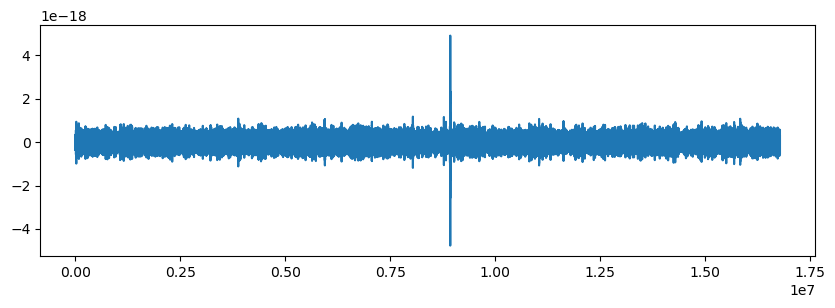

In [5]:
plt.figure(figsize=(10,3))
plt.plot(y)
plt.show()

In [6]:
acf = autocorrelation(y)

: 

In [7]:
lags = np.arange(0,300)
autocorr_values = [autocorrelation(y, lag) for lag in lags]
print("Autocorrelation values for different lags:", autocorr_values)



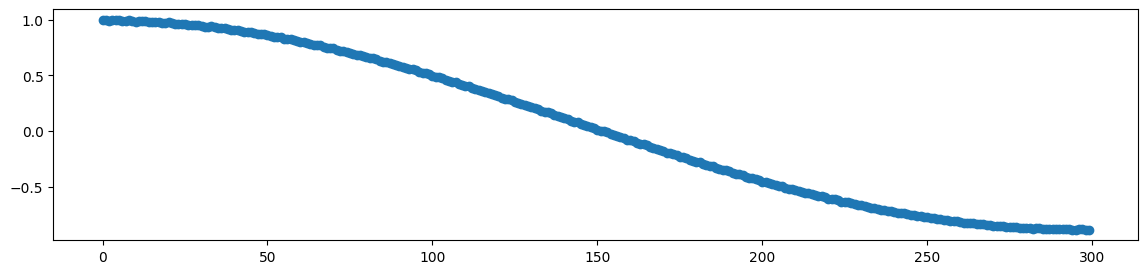

In [ ]:
plt.figure(figsize=(14,3))
plt.plot(acf[:300],'o')
plt.show()